<a href="https://colab.research.google.com/github/Aastha210/202401100300004_DigitDetection/blob/main/Cat_Dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving training_set.zip to training_set (1).zip


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving test_set.zip to test_set (1).zip


In [ ]:
import zipfile

with zipfile.ZipFile("training_set.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

with zipfile.ZipFile("test_set.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/")

In [ ]:
import os
os.listdir("/content/")

['.config',
 'test_set',
 'training_set (1).zip',
 '.ipynb_checkpoints',
 'training_set',
 'test_set (1).zip',
 'sample_data']

In [ ]:
train_dir = "/content/training_set"
test_dir  = "/content/test_set"

In [ ]:
IMG_SIZE = (150,150)
BATCH_SIZE = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.


In [ ]:
normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 417s 2s/step - accuracy: 0.5056 - loss: 0.7112 - val_accuracy: 0.6303 - val_loss: 0.6639
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 438s 2s/step - accuracy: 0.6328 - loss: 0.6531 - val_accuracy: 0.6065 - val_loss: 0.6815
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 407s 2s/step - accuracy: 0.7050 - loss: 0.5788 - val_accuracy: 0.7316 - val_loss: 0.5501
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 412s 2s/step - accuracy: 0.7648 - loss: 0.4842 - val_accuracy: 0.7627 - val_loss: 0.5124
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 412s 2s/step - accuracy: 0.8137 - loss: 0.4219 - val_accuracy: 0.7553 - val_loss: 0.5157
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 403s 2s/step - accuracy: 0.8446 - loss: 0.3554 - val_accuracy: 0.7800 - val_loss: 0.5255
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 432s 2s/step - accuracy: 0.8702 - loss: 0.3005 - val_accuracy: 0.7810 - val_loss: 0.5444
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 454s 2s/step - accuracy: 0.9074 - loss: 0.2315 - val_accu

In [ ]:
loss, accuracy = model.evaluate(val_ds)
print("Validation Accuracy:", accuracy)

64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 450ms/step - accuracy: 0.7722 - loss: 0.7629
Validation Accuracy: 0.7671774625778198


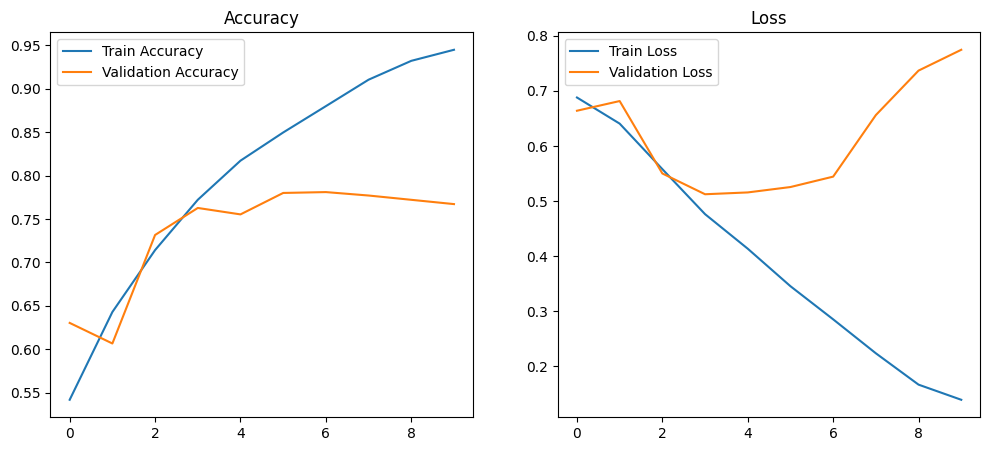

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [ ]:
img = image.load_img("/content/100.jpg", target_size=(150,150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Dog 🐶")
else:
    print("Cat 🐱")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
Cat 🐱


In [ ]:
img = image.load_img("/content/4.jpg", target_size=(150,150))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Dog 🐶")
else:
    print("Cat 🐱")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Dog 🐶
